# Coding Practice \#2: Due February 14th at midnight in Canvas

file needed = 'monthly_loc_rides.csv', 'two_digit_by_port.csv', 'port_codes.csv'

Answer the questions below in a Jupyter notebook. You can modify this notebook by adding cells with your answers.

In [7]:
# Load packages needed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# os.chdir('C:/Users/messy/Desktop/School/ECON570') 
os.chdir('/Users/jackson/Documents/ECON570') #macbook dir

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt


## Exercise 0: Kaiman, Jackson
Replace 'Last, First' above with your actual name. Enter it as your last name, first name.

## Exercise 1: Nuclear Waste Cleanup

*Source:* This is a modification of a problem that Google often uses as a coding exam to recruit software engineers.

*Setup:* You are in charge of the U.S. nuclear waste cleanup program, and you are tasked with cleaning 1,000 units of nuclear waste. Your assignment is to identify the lowest cost cleanup method.

In order to clean up nuclear waste, you must manage the building and operation of nuclear cleanup sites around the country. These sites are expensive to both build and operate. In particular, the cost of building a cleanup site is $\$2,000,000$ and the cost per day of operation is $\$75,000$. It is expected that a site tasked with cleaning up $N$ units of waste will require $$N+0.01N^2$$ days of operation.

*How to assign waste to sites:* It turns out that the lowest cost strategy is to split the waste evenly across sites. In other words, if I choose to build 4 nuclear waste sites, then each of those four sites should clean exactly $1000/4=250$ units of nuclear waste.

*Your task:* Congress has capped the maximum number of nuclear waste sites at 10. Your job is find the number of nuclear waste sites that is associated with the lowest cost of cleaning up all 1,000 units of waste.

### Part (a):

You should write code to solve this problem. Here are the steps for the solution:

1. Loop over each possible number of sites and print out a nicely formatted answer like this: "If I build 4 nuclear cleanup sites, then each site will clean 250 units of nuclear waste."

In [9]:
total_waste = 1000
for sites in range(1,11):
    units_per_site = total_waste / sites
    units_str = f"{int(units_per_site)}" if units_per_site.is_integer() else f"{units_per_site:.2f}"
    label = "site" if sites == 1 else "sites"
    print(f"If I build {sites} nuclear cleanup {label}, then each site will clean {units_str} units of nuclear waste.")


If I build 1 nuclear cleanup site, then each site will clean 1000 units of nuclear waste.
If I build 2 nuclear cleanup sites, then each site will clean 500 units of nuclear waste.
If I build 3 nuclear cleanup sites, then each site will clean 333.33 units of nuclear waste.
If I build 4 nuclear cleanup sites, then each site will clean 250 units of nuclear waste.
If I build 5 nuclear cleanup sites, then each site will clean 200 units of nuclear waste.
If I build 6 nuclear cleanup sites, then each site will clean 166.67 units of nuclear waste.
If I build 7 nuclear cleanup sites, then each site will clean 142.86 units of nuclear waste.
If I build 8 nuclear cleanup sites, then each site will clean 125 units of nuclear waste.
If I build 9 nuclear cleanup sites, then each site will clean 111.11 units of nuclear waste.
If I build 10 nuclear cleanup sites, then each site will clean 100 units of nuclear waste.


2. For each possible number of sites, calculate the total cost of cleanup using the formula above.

In [10]:
build_cost_per_site = 2000000
op_cost_per_day = 75000
results = []


for sites in range (1,11):
    N = total_waste / sites
    days_per_site = N + 0.01 * (N ** 2)
    total_build = build_cost_per_site * sites
    total_operating = op_cost_per_day * days_per_site * sites
    total_cost = total_build + total_operating
    results.append((sites, total_cost))
    print(f"{sites:2d} site(s): total cost = ${total_cost:,.2f}")

 1 site(s): total cost = $827,000,000.00
 2 site(s): total cost = $454,000,000.00
 3 site(s): total cost = $331,000,000.00
 4 site(s): total cost = $270,500,000.00
 5 site(s): total cost = $235,000,000.00
 6 site(s): total cost = $212,000,000.00
 7 site(s): total cost = $196,142,857.14
 8 site(s): total cost = $184,750,000.00
 9 site(s): total cost = $176,333,333.33
10 site(s): total cost = $170,000,000.00


3. What is the cost-minimizing number of sites? Use your coding skills and Python functions to keep track of the costs, find the minimum, and print out the optimal number of sites. Do not do this manually.

In [11]:
def total_cost_for_sites(sites: int) -> float:
    N = total_waste / sites  # units per site
    days_per_site = N + 0.01 * (N ** 2)
    total_build = build_cost_per_site * sites
    total_operating = op_cost_per_day * days_per_site * sites
    return total_build + total_operating


costs = [(s, total_cost_for_sites(s)) for s in range(1, 11)]
best_sites, best_cost = min(costs, key=lambda t: t[1])


print(f"Optimal # of sites: {best_sites}")
print(f"Minimum total cost: {best_cost:,.2f}")

Optimal # of sites: 10
Minimum total cost: 170,000,000.00


### Part (b):

Assume further that waste units are indivisible, so sites may not clean a fractional number of waste units. For example, you can not evenly divide 1,000 units across 3 sites without breaking up the units. So, building 3 sites is no longer an option.

Augment your code from part (a) to solve the modified problem. \[Hint: Consder using `a % b` which returns the remainder of $a \div b$.]

In [12]:

valid_results = []

for sites in range(1, 11):
    if total_waste % sites == 0:
        N = total_waste // sites
        cost = total_cost_for_sites(sites)
        valid_results.append((sites, cost))
        print(f"{sites:2d} site(s): {N} units/site, total cost = ${cost:,.2f}")
    else:
        print(f"{sites:2d} site(s): not allowed (1000 not divisible by {sites})")

if valid_results:
    best_sites, best_cost = min(valid_results, key=lambda t: t[1])
    print(f"\nOptimal number of sites (indivisible units): {best_sites}")
    print(f"Minimum total cost: ${best_cost:,.2f}")
else:
    print("\nNo valid site counts under indivisibility constraint.")

 1 site(s): 1000 units/site, total cost = $827,000,000.00
 2 site(s): 500 units/site, total cost = $454,000,000.00
 3 site(s): not allowed (1000 not divisible by 3)
 4 site(s): 250 units/site, total cost = $270,500,000.00
 5 site(s): 200 units/site, total cost = $235,000,000.00
 6 site(s): not allowed (1000 not divisible by 6)
 7 site(s): not allowed (1000 not divisible by 7)
 8 site(s): 125 units/site, total cost = $184,750,000.00
 9 site(s): not allowed (1000 not divisible by 9)
10 site(s): 100 units/site, total cost = $170,000,000.00

Optimal number of sites (indivisible units): 10
Minimum total cost: $170,000,000.00


## Exercise 2: Seaborn

The file `monthly_loc_rides.csv` is taken from [Chicago's Open Data Portal](https://data.cityofchicago.org/). The dataset is a monthly time-series by location on ride-sharing platforms in the city of Chicago. There are a few variables:
- `year` : the year of the ride
- `month` : the month of the ride
- `location` : the community area (location) of the origin of the ride
- `avg_fare` : how much Uber, Lyft, and other ride-share companies charged (average)
- `miles` : how far the ride was (in miles, average)
- `num_rides` : the number of rides in a month-location

The goal of this question is to use multiple visualization tools in the same figure, to understand the relationship between two variables.

### Part (a): Load the data

Read `monthly_loc_rides.csv` into a DataFrame named `monthly_loc_rides`. Make sure to drop observations where `location` is missing. How many observations were dropped? Print it out.

In [13]:
df = pd.read_csv("data/p2/monthly_loc_rides.csv", na_values= "NA, na,  , NaN")
dropped = df['location'].isna().sum()
monthly_loc_rides = df.dropna(subset=['location']).copy()
print(f"{dropped} N/A values were dropped")
monthly_loc_rides


50 N/A values were dropped


,year,month,location,avg_fare,avg_miles,num_rides
0,2018,11,1.0,10.645126,5.917467,97946
1,2018,11,2.0,9.895857,5.582752,70744
2,2018,11,3.0,9.948583,5.298680,185151
3,2018,11,4.0,10.123744,5.070587,88954
4,2018,11,5.0,10.014318,4.787730,103538
...,...,...,...,...,...,...
3894,2022,12,73.0,14.859533,7.438620,22977
3895,2022,12,74.0,16.044063,7.459407,5912
3896,2022,12,75.0,15.836450,8.009189,17646
3897,2022,12,76.0,32.211564,17.619063,264157


### Part (b): Create a regplot

Use `seaborn` to explore the relationship between fares and distance. To begin, create a regplot of fares vs. distance, removing the top and right spines and making the markers in the scatterplot transparent (with some alpha less than .25). Comment on what you see. 

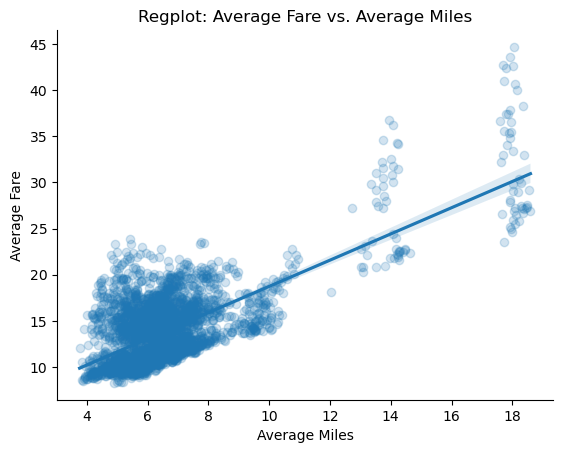

In [14]:
sns.regplot(
    data=monthly_loc_rides,
    x='avg_miles',
    y='avg_fare',
    scatter_kws={'alpha': 0.2}
)
sns.despine(top=True, right=True)
plt.xlabel('Average Miles')
plt.ylabel('Average Fare')
plt.title('Regplot: Average Fare vs. Average Miles')
plt.show()

### Part (c): Create a bubble plot

Use the above exploration to create a new DataFrame that focuses on the data corresponding to the first peak of the travel distance distribution (i.e., observations with ~11 or less average distance). With that DataFrame, create a bubble plot of average fare vs. average miles, with a regplot overlaid. Use the following specifications: 
1. The x-axis should be average fare and the y-axis should be average miles.
2. Add a 95% confidence interval around a red regression line.
3. The bubble plot should be purple. Use alpha to make the bubbles lighter than the regression line.
4. Bubbles should be scaled proportionally to the number of rides.

Briefly comment on your results. What share of the original dataset's observations are in your new dataset? Does fare seem to scale linearly in price?

Share of observations in new dataset: 97.43%


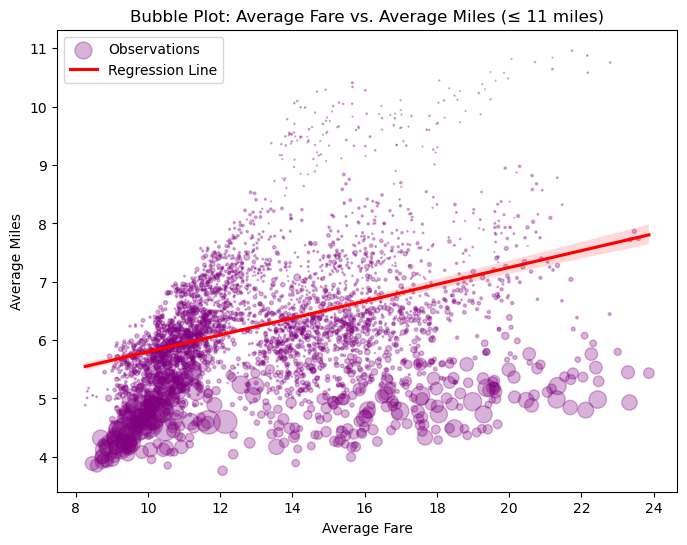

In [15]:
bubble_df = monthly_loc_rides[monthly_loc_rides['avg_miles'] <= 11].copy()

share = len(bubble_df) / len(monthly_loc_rides)
print(f"Share of observations in new dataset: {share:.2%}")

plt.figure(figsize=(8, 6))
plt.scatter(
    bubble_df['avg_fare'],
    bubble_df['avg_miles'],
    s=bubble_df['num_rides'] / bubble_df['num_rides'].max() * 300,
    color='purple',
    alpha=0.3,
    label='Observations'
)
sns.regplot(
    data=bubble_df,
    x='avg_fare',
    y='avg_miles',
    scatter=False,
    color='red',
    ci=95,
    label='Regression Line'
)
plt.xlabel('Average Fare')
plt.ylabel('Average Miles')
plt.title('Bubble Plot: Average Fare vs. Average Miles (≤ 11 miles)')
plt.legend()
plt.show()

## Exercise 3: MultiIndex

Let's practice using a MultiIndex to select observations from data with multiple dimensions. The file 'two_digit_by_port.csv' contains U.S. the dollar value of imports by two-digit commodity code and port of entry for December 2013. 

For example, imports into port number 3703 (Green Bay, WI) of commodity 72 (Iron and Steel) were $9,208,917 in December 2013.

You can learn about port codes [here](https://www.census.gov/foreign-trade/schedules/d/distcode.html).<br>
The data were retrieved from the [Census trade API](https://www.census.gov/data/developers/data-sets/international-trade.html). 

### Part (a): Load the data

1. Load 'two_digit_by_port.csv' into a DataFrame.
2. Check the data types. `I_COMMODITY` should be integers and `GEN_VAL_YR` should be floats. All others should be objects.

In [16]:
two_digit_by_port = pd.read_csv('data/p2/two_digit_by_port.csv', dtype={'I_COMMODITY': int, 'GEN_VAL_YR': float})
print(two_digit_by_port.dtypes)

PORT                  object
I_COMMODITY            int64
GEN_VAL_YR           float64
I_COMMODITY_SDESC     object
COMM_LVL              object
time                  object
dtype: object


### Part (b): Set up the index

1. Set the index to be `PORT`, `I_COMMODITY`, and `I_COMMODITY_SDESC`, in that order.
2. Sort the index and store as a new DataFrame called `part_b`.
3. Print out the first 3 and last 3 rows of `part_b`.

   Note that the `-` port is the total for all ports. This is why PORT is an object and not an int.

In [17]:
part_b = two_digit_by_port.set_index(['PORT', 'I_COMMODITY', 'I_COMMODITY_SDESC']).sort_index()
print(part_b.head(3))
print(part_b.tail(3))

                                                              GEN_VAL_YR  \
PORT I_COMMODITY I_COMMODITY_SDESC                                         
-    1           LIVE ANIMALS                               2.638842e+09   
     2           MEAT AND EDIBLE MEAT OFFAL                 5.844460e+09   
     3           FISH, CRUSTACEANS & AQUATIC INVERTEBRATES  1.389178e+10   

                                                           COMM_LVL     time  
PORT I_COMMODITY I_COMMODITY_SDESC                                            
-    1           LIVE ANIMALS                                   HS2  2013-12  
     2           MEAT AND EDIBLE MEAT OFFAL                     HS2  2013-12  
     3           FISH, CRUSTACEANS & AQUATIC INVERTEBRATES      HS2  2013-12  
                                                             GEN_VAL_YR  \
PORT I_COMMODITY I_COMMODITY_SDESC                                        
6000 89          SHIPS, BOATS AND FLOATING STRUCTURES      1.143831e+07   

### Part (c): Indexing

1. Print out the row that corresponds to port = 3002 and commodity code = 95 (toys and games).

In [18]:
print(part_b.loc[('3002', 95)])

                                                      GEN_VAL_YR COMM_LVL  \
I_COMMODITY_SDESC                                                           
TOYS, GAMES & SPORT EQUIPMENT; PARTS & ACCESSORIES  2.296905e+09      HS2   

                                                       time  
I_COMMODITY_SDESC                                            
TOYS, GAMES & SPORT EQUIPMENT; PARTS & ACCESSORIES  2013-12  


### Part (d): Partial indexing
1. Retrieve all the rows that correspond to commodity code = 87 (Vehicles) and create a DataFrame from those rows named `part_d`. You might want to use the `.xs()` method here.
2. Print out the first 4 rows of `part_d`.

3. Drop the row that corresponds to port = '-' and store as a DataFrame called `part_d2`. 
4. Print out the first 4 rows of `part_d2`.

5. Report the total value of imports of vehicles from `part_d2`. Report the number using commas to separate the thousands and no digits to the right of the decimal point.

6. Report the total value of imports of vehicles reported by port = '-'. Report the number using commas to separate the thousands and no digits to the right of the decimal point.

Does it match your answer from part 5?

In [19]:
part_b = two_digit_by_port.set_index(['PORT', 'I_COMMODITY', 'I_COMMODITY_SDESC']).sort_index()

# Step 1:
part_d = part_b.xs(87, level='I_COMMODITY')
print(part_d.head(4))

# Step 2: 
part_d2 = part_d.drop('-', errors='ignore')
print(part_d2.head(4))

# Step 3:
total_vehicles_imports = part_d2['GEN_VAL_YR'].sum()
print(f"Total value of imports of vehicles from part_d2: {total_vehicles_imports}")

# Step 4: 
total_vehicles_imports_dash = part_d.loc['-', 'GEN_VAL_YR']
print(f"Total value of imports of vehicles reported by port = '-': {total_vehicles_imports_dash}")

# Step 5: 
if total_vehicles_imports == total_vehicles_imports_dash.item():
    print("Yes, the totals match.")
else:
    print("No, the totals do not match.")
#6
print(f"Total value of imports of vehicles from part_d2: {total_vehicles_imports}")


                                                           GEN_VAL_YR  \
PORT I_COMMODITY_SDESC                                                  
-    VEHICLES, EXCEPT RAILWAY OR TRAMWAY, AND PARTS ETC  2.490175e+11   
0101 VEHICLES, EXCEPT RAILWAY OR TRAMWAY, AND PARTS ETC  4.715070e+05   
0102 VEHICLES, EXCEPT RAILWAY OR TRAMWAY, AND PARTS ETC  2.496000e+03   
0104 VEHICLES, EXCEPT RAILWAY OR TRAMWAY, AND PARTS ETC  1.705561e+07   

                                                        COMM_LVL     time  
PORT I_COMMODITY_SDESC                                                     
-    VEHICLES, EXCEPT RAILWAY OR TRAMWAY, AND PARTS ETC      HS2  2013-12  
0101 VEHICLES, EXCEPT RAILWAY OR TRAMWAY, AND PARTS ETC      HS2  2013-12  
0102 VEHICLES, EXCEPT RAILWAY OR TRAMWAY, AND PARTS ETC      HS2  2013-12  
0104 VEHICLES, EXCEPT RAILWAY OR TRAMWAY, AND PARTS ETC      HS2  2013-12  
                                                         GEN_VAL_YR COMM_LVL  \
PORT I_COMMODITY_SDESC   

## Ungraded Bonus Exercise: Merge

Let's walk through a merge example. We'll merge the data from the previous problem with data from 'port_codes.csv'.

### Part (a): Load the data and match the key types

1. Read in 'port_codes.csv' as `names`. Check the dtypes.

Let's update the DataFrame from the previous problem stored as `part_b` so the PORT column is also an integer.

2. Drop the row that corresponds to port = '-' and store as a DataFrame called `part_b2`.
3. Reset the index of `part_b2` and convert the PORT column to integers.

### Part (b): Merge the data

1. Now merge `names` with `part_b2` on the key PORT as an outer join. Include `indicator=True`.

2. Are there ports in `names` that are not in `part_b2`? Are there ports in `part_b2` that are not in `names`?